In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]


In [5]:
df = pd.read_csv("..//Dataset//adult.data",names=column_names)

In [6]:
df.head(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.shape

(32561, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.duplicated().sum()

24

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
print(df.isnull().sum())


age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


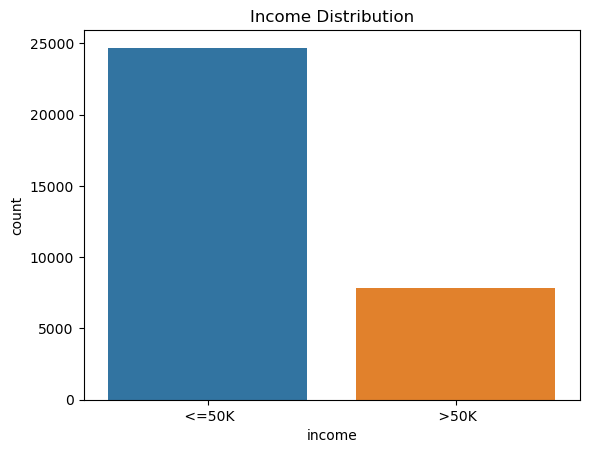

In [13]:
sns.countplot(x='income', data=df)
plt.title('Income Distribution')
plt.show()


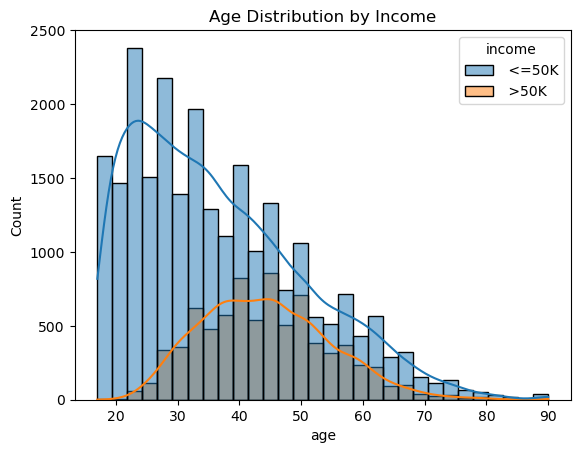

In [14]:
sns.histplot(data=df, x='age', hue='income', kde=True, bins=30)
plt.title('Age Distribution by Income')
plt.show()

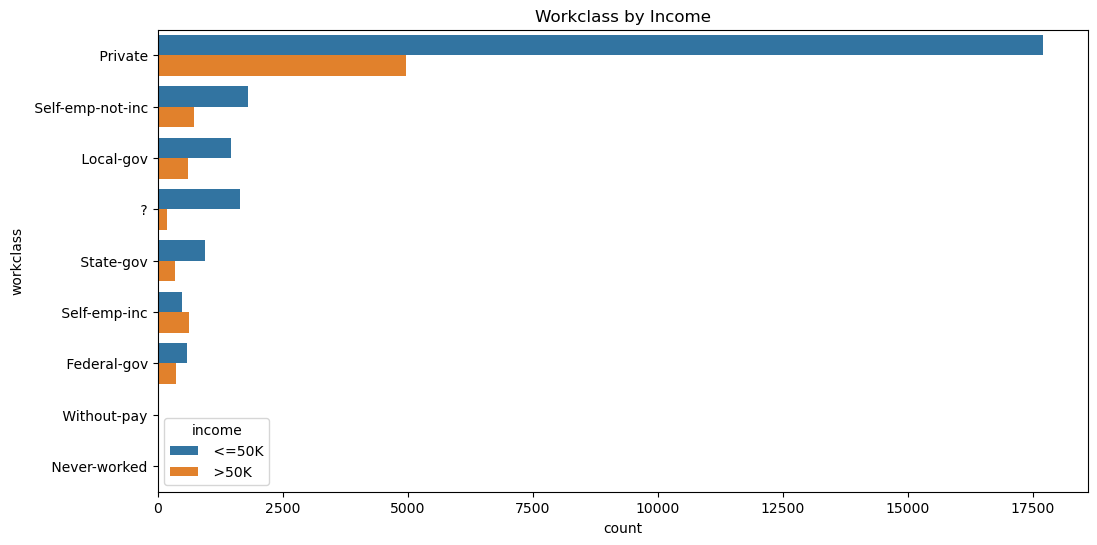

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(y='workclass', hue='income', data=df, order=df['workclass'].value_counts().index)
plt.title('Workclass by Income')
plt.show()


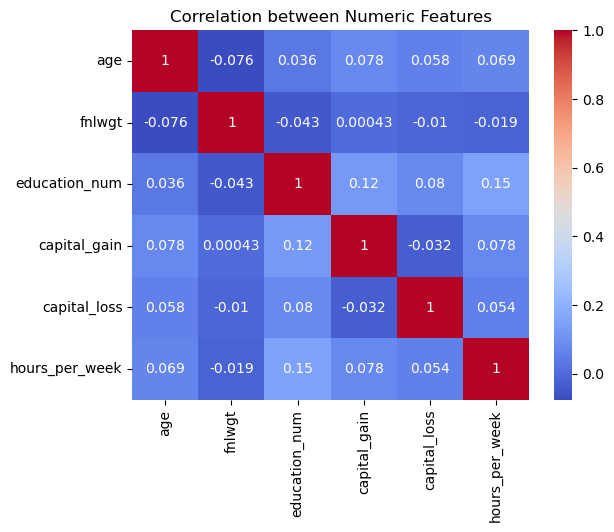

In [16]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
sns.heatmap(df[numeric_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Numeric Features')
plt.show()


In [17]:
df.drop(['fnlwgt'], axis=1, inplace=True)


In [18]:
from sklearn.preprocessing import LabelEncoder

# Encode all object (string) type columns
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [19]:
df.head()

,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,9,13,2,10,5,2,0,0,0,40,5,0


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
print(X_test.shape)
print(X_train.shape)

(6508, 13)
(26029, 13)


In [24]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [25]:
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)


DecisionTreeClassifier()

In [26]:
model3 = RandomForestClassifier()
model3.fit(X_train, y_train)

RandomForestClassifier()

In [27]:
model4 = GradientBoostingClassifier()
model4.fit(X_train, y_train)

GradientBoostingClassifier()

In [28]:
model5 = SVC(probability=True)
model5.fit(X_train, y_train)

SVC(probability=True)

In [29]:
model6 = KNeighborsClassifier()
model6.fit(X_train, y_train)

KNeighborsClassifier()

In [30]:

models = [model1, model2, model3, model4, model5,model6]
names = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM','KNN']

for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    print(f"----{name}----")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


----Logistic Regression----
Accuracy: 0.8254456054087277
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4905
           1       0.73      0.46      0.57      1603

    accuracy                           0.83      6508
   macro avg       0.79      0.70      0.73      6508
weighted avg       0.82      0.83      0.81      6508

----Decision Tree----
Accuracy: 0.8156115550092194
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4905
           1       0.63      0.62      0.62      1603

    accuracy                           0.82      6508
   macro avg       0.75      0.75      0.75      6508
weighted avg       0.81      0.82      0.82      6508

----Random Forest----
Accuracy: 0.8509526736324524
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4905
           1       0.73      0.63      0.68      1603

    accuracy           

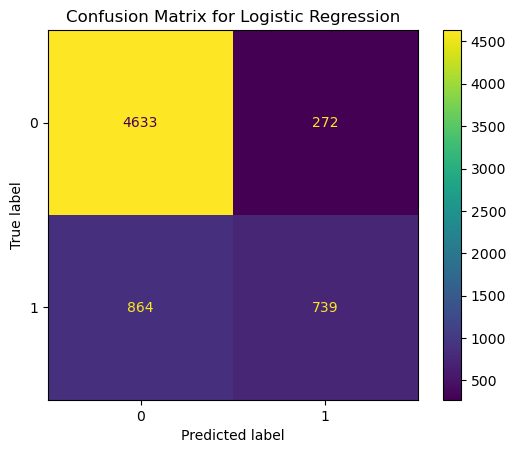

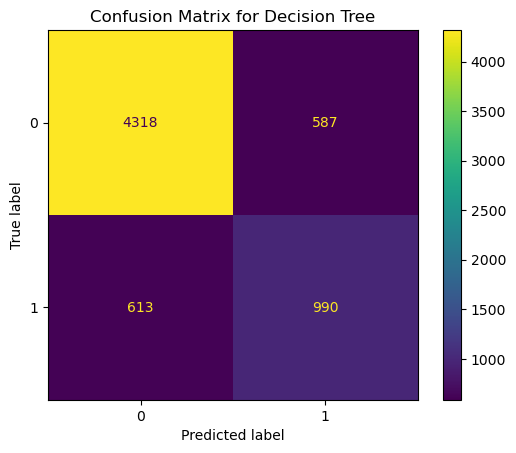

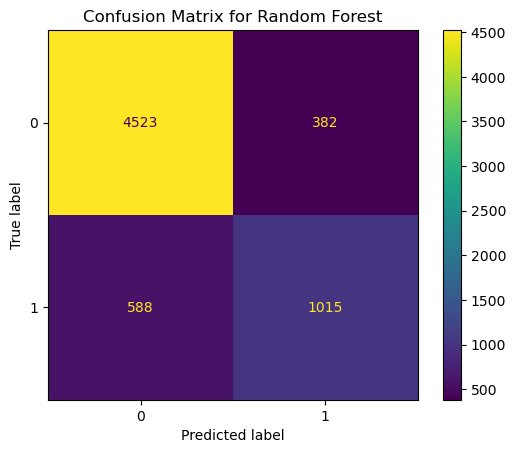

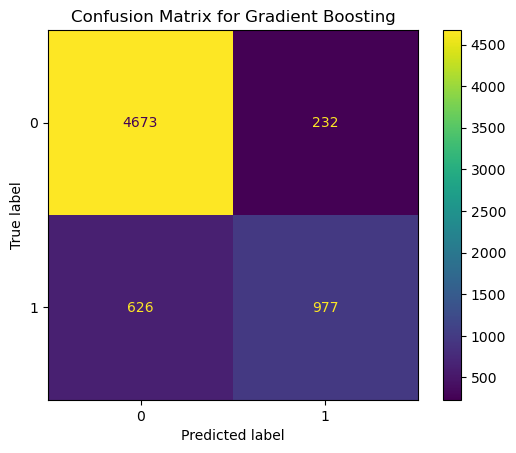

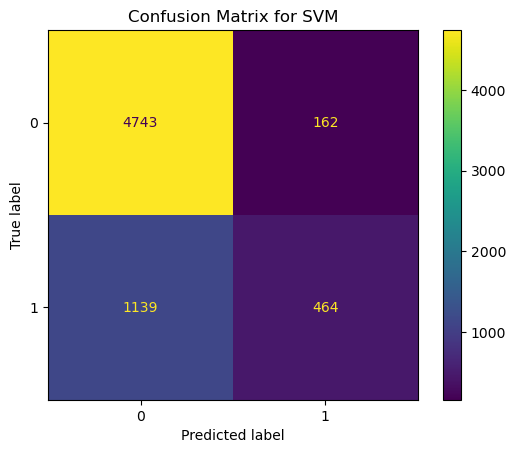

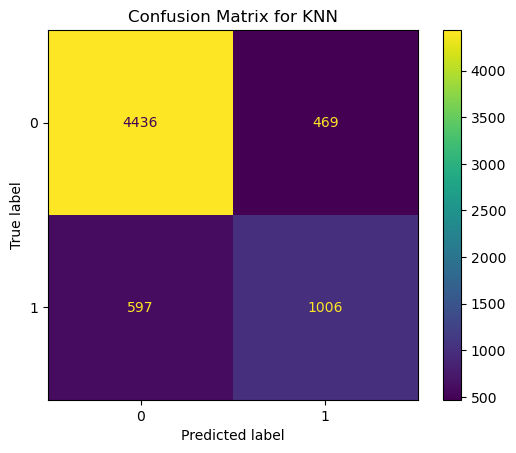

In [31]:
for model, name in zip(models, names):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix for {name}")
plt.show()

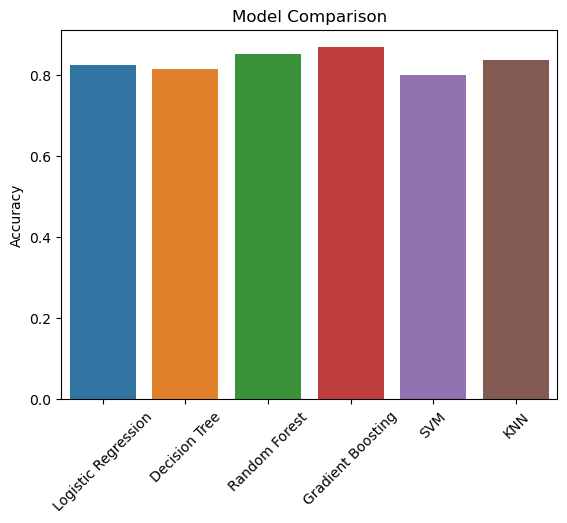

In [32]:
accuracies = [accuracy_score(y_test, model.predict(X_test)) for model in models]
sns.barplot(x=names, y=accuracies)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.title('Model Comparison')
plt.show()


In [33]:
for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    print(f"---{name}---")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))


---Logistic Regression---
Precision: 0.7309594460929772
Recall: 0.4610106051154086
F1 Score: 0.5654169854628921
---Decision Tree---
Precision: 0.6277742549143944
Recall: 0.6175920149719276
F1 Score: 0.6226415094339623
---Random Forest---
Precision: 0.7265569076592698
Recall: 0.6331877729257642
F1 Score: 0.6766666666666666
---Gradient Boosting---
Precision: 0.8081058726220016
Recall: 0.6094822208359326
F1 Score: 0.6948790896159318
---SVM---
Precision: 0.7412140575079872
Recall: 0.2894572676232065
F1 Score: 0.4163301929116196
---KNN---
Precision: 0.6820338983050848
Recall: 0.627573300062383
F1 Score: 0.6536712150747238


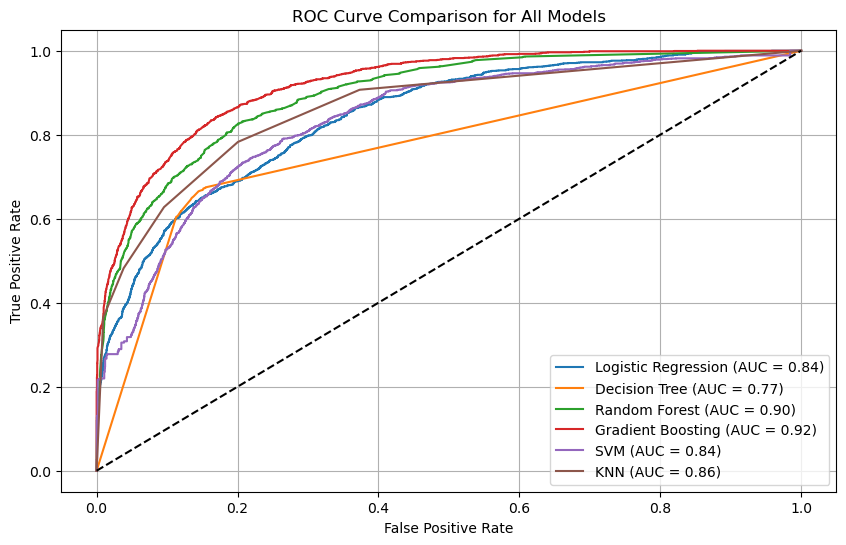

In [34]:
plt.figure(figsize=(10, 6))

for model, name in zip(models, names):
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)
        
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for All Models")
plt.legend(loc="lower right")
plt.grid()
plt.show()

### Interpretation
Random Forest and Gradient Boosting typically perform very well on this dataset.

Logistic Regression is a strong baseline.

SVM and KNN may take longer and might require tuning.

Look for models with higher accuracy and ROC-AUC.

Analyze classification reports to understand precision, recall, and F1-score per class.

